# Factor Momentum: Replication and Extension

**Replicating and extending the findings of Ehsani & Linnainmaa (2022) and Arnott, Kalesnik & Linnainmaa (2023)**

This project investigates whether equity risk factors exhibit momentum; do factors that performed well over the prior year continue to outperform? The key claim from the literature is that the well-known stock-level momentum anomaly is largely a reflection of this factor-level autocorrelation rather than a distinct phenomenon.

**What this project does:**
1. Constructs four equity factors (HML, PMU, CMA, UMD) from raw CRSP and Compustat data using Fama-French methodology
2. Tests whether these factors are positively autocorrelated
3. Builds time-series and cross-sectional factor momentum strategies
4. Evaluates whether factor momentum profits are explained by existing asset pricing models
5. Implements a long-only factor rotation strategy and a PCA-based extension

**Data:** CRSP monthly stock returns, Compustat annual accounting data, Fama-French factor returns (July 1963 – December 2022)

**References:**
- Ehsani, S. and Linnainmaa, J.T. (2022). *Factor Momentum and the Momentum Factor.* Journal of Finance, 77(3), 1877–1919.
- Arnott, R., Kalesnik, V., and Linnainmaa, J.T. (2023). *Factor Momentum.* Review of Financial Studies, 36(8), 3034–3070.

#### Imports

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.tseries.offsets import MonthEnd
import statsmodels.api as sm
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

---
## 1. Data Preparation

All four factors require CRSP monthly return data and Compustat annual accounting data. The merge requires careful attention to timing — annual financial statements take several months to be reported, so we follow the standard convention and assume fiscal-year $t$ accounting data is not available until the end of June of calendar year $t+1$ (6-month reporting lag). Using data earlier than this introduces look-ahead bias.

### 1.1 CRSP Monthly Returns

In [28]:
# File Paths
data_path = '/Users/hannahattar/Desktop/Python/quantitative_investing/Midterm'

# Load CRSP monthly stock data
crsp = pd.read_feather(f'{data_path}/crsp_monthly_stocks.feather')

# Keep relevant columns and filter to common stocks (SHRCD 10, 11)
crsp = crsp[['PERMNO', 'DATE', 'SHRCD', 'EXCHCD', 'PRC', 'RET', 'SHROUT']].copy()
crsp = crsp[crsp['SHRCD'].isin([10, 11])].copy()

# Type conversions
crsp['DATE'] = pd.to_datetime(crsp['DATE'])
crsp['RET'] = pd.to_numeric(crsp['RET'], errors='coerce')
crsp['PERMNO'] = crsp['PERMNO'].astype(int)

# Market capitalization (in millions)
crsp['ME'] = crsp['PRC'].abs() * crsp['SHROUT'] / 1000

# Drop missing returns and non-positive market equity
crsp = crsp.dropna(subset=['RET'])
crsp = crsp[crsp['ME'] > 0].copy()

# Sample period: July 1963 – December 2022
crsp = crsp[(crsp['DATE'] >= '1963-07-01') & (crsp['DATE'] <= '2022-12-31')].copy()

# Microcap screen: drop bottom 5% of market cap each month
me_cutoff = crsp.groupby('DATE')['ME'].quantile(0.05)
crsp = crsp.merge(me_cutoff.rename('ME_5pct'), on='DATE', how='left')
crsp = crsp[crsp['ME'] >= crsp['ME_5pct']].drop(columns=['ME_5pct']).copy()

crsp = crsp.set_index(['PERMNO', 'DATE']).sort_index()

print(f"CRSP: {crsp.shape[0]:,} firm-months")

CRSP: 3,108,653 firm-months
                   SHRCD  EXCHCD       PRC       RET  SHROUT         ME
PERMNO DATE                                                            
10000  1986-02-28   10.0     3.0 -3.250000 -0.257143  3680.0  11.960000
       1986-03-31   10.0     3.0 -4.437500  0.365385  3680.0  16.330000
       1986-04-30   10.0     3.0 -4.000000 -0.098592  3793.0  15.172000
       1986-05-30   10.0     3.0 -3.109375 -0.222656  3793.0  11.793859
       1986-06-30   10.0     3.0 -3.093750 -0.005025  3793.0  11.734594
       1986-07-31   10.0     3.0 -2.843750 -0.080808  3793.0  10.786344
       1986-08-29   10.0     3.0 -1.093750 -0.615385  3793.0   4.148594
       1986-09-30   10.0     3.0 -1.031250 -0.057143  3793.0   3.911531
       1986-10-31   10.0     3.0 -0.781250 -0.242424  3843.0   3.002344
       1986-11-28   10.0     3.0 -0.828125  0.060000  3843.0   3.182484


### 1.2 Compustat Annual Accounting Data

In [13]:
# Load Compustat annual data
comp = pd.read_feather(f'{data_path}/compustat_annual.feather')

comp = comp[['LPERMNO', 'DATADATE', 'FYEAR', 'SEQ', 'PSTK', 'SALE', 'CAPX', 'AT']].copy()
comp = comp.rename(columns={'LPERMNO': 'PERMNO'})

# Type conversions
comp['DATADATE'] = pd.to_datetime(comp['DATADATE'])
comp['FYEAR'] = pd.to_numeric(comp['FYEAR'], errors='coerce')
for col in ['SEQ', 'PSTK', 'SALE', 'CAPX', 'AT']:
    comp[col] = pd.to_numeric(comp[col], errors='coerce')

# Keep most recent filing per firm-year
comp = comp.sort_values(['PERMNO', 'FYEAR', 'DATADATE'])
comp = comp.drop_duplicates(subset=['PERMNO', 'FYEAR'], keep='last')
comp = comp[comp['AT'].notna() & (comp['AT'] > 0)].copy()

# Book equity
comp['PSTK'] = comp['PSTK'].fillna(0).clip(lower=0)
comp['BE'] = comp['SEQ'] - comp['PSTK']
comp = comp[comp['BE'].notna() & (comp['BE'] > 0)].copy()

# Operating profitability: OP = (Sales - CapEx) / Total Assets
comp.loc[comp['SALE'] < 0, 'SALE'] = np.nan
comp['OP'] = (comp['SALE'] - comp['CAPX']) / comp['AT']

# Investment signal: asset growth
comp = comp.sort_values(['PERMNO', 'FYEAR'])
comp['AT_lag'] = comp.groupby('PERMNO')['AT'].shift(1)
comp['INV'] = np.where(comp['AT_lag'] > 0,
                       (comp['AT'] - comp['AT_lag']) / comp['AT_lag'], np.nan)
comp = comp.drop(columns=['AT_lag'])

# Winsorize OP and INV at 1st/99th percentile
for col in ['OP', 'INV']:
    comp[col] = comp[col].clip(lower=comp[col].quantile(0.01),
                               upper=comp[col].quantile(0.99))

# Apply 6-month reporting lag: fiscal year t available after June t+1
comp['DATE'] = pd.to_datetime((comp['FYEAR'] + 1).astype(int).astype(str) + '-06-30')
comp['DATE'] = comp['DATE'] + pd.offsets.MonthEnd(0)

comp = comp.set_index(['PERMNO', 'DATE']).sort_index()
print(f"Compustat: {comp.shape[0]:,} firm-years")

Compustat: 284,035 firm-years


### 1.3 CRSP–Compustat Merge

In [14]:
# Merge using June rebalance dates to avoid look-ahead bias
crsp_reset = crsp.reset_index()
comp_reset = comp.reset_index()

# For each CRSP month, determine which fiscal year's data is available
crsp_reset['JDATE'] = crsp_reset['DATE'].dt.year
crsp_reset.loc[crsp_reset['DATE'].dt.month <= 6, 'JDATE'] = crsp_reset['JDATE'] - 1
crsp_reset['JDATE'] = pd.to_datetime(crsp_reset['JDATE'].astype(int).astype(str) + '-06-30')

comp_reset = comp_reset.rename(columns={'DATE': 'JDATE'})
merged = crsp_reset.merge(comp_reset[['PERMNO', 'JDATE', 'BE', 'OP', 'INV']],
                          on=['PERMNO', 'JDATE'], how='inner')
merged = merged.drop(columns=['JDATE'])

# Book-to-market ratio
merged['BM'] = merged['BE'] / merged['ME']

# Monthly winsorization of signals
def winsorize_by_month(df, col):
    low = df.groupby('DATE')[col].transform(lambda x: x.quantile(0.01))
    high = df.groupby('DATE')[col].transform(lambda x: x.quantile(0.99))
    df[col] = df[col].clip(lower=low, upper=high)
    return df

for col in ['BM', 'OP', 'INV']:
    merged = winsorize_by_month(merged, col)

merged = merged.dropna(subset=['RET', 'BM', 'OP', 'INV']).copy()
merged = merged.set_index(['PERMNO', 'DATE']).sort_index()
print(f"Merged panel: {merged.shape[0]:,} firm-months")

Merged panel: 2,135,050 firm-months


### 1.4 Fama-French Benchmark Factors

In [15]:
midterm_path_ff5 = '../Midterm/F-F_Research_Data_5_Factors_2x3.csv'
midterm_path_mom = '../Midterm/F-F_Momentum_Factor.csv'

# 5-factor data
ff5 = pd.read_csv(midterm_path_ff5, skiprows=4)
ff5 = ff5.rename(columns={ff5.columns[0]: 'DATE'})
ff5['DATE'] = ff5['DATE'].astype(str).str.strip()
ff5 = ff5[ff5['DATE'].str.len() == 6].copy()
ff5['DATE'] = pd.to_datetime(ff5['DATE'], format='%Y%m') + MonthEnd(0)
for col in ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']:
    ff5[col] = pd.to_numeric(ff5[col], errors='coerce') / 100

# Load momentum factor
mom = pd.read_csv(midterm_path_mom, skiprows=13)
mom = mom.rename(columns={mom.columns[0]: 'DATE'})
mom['DATE'] = mom['DATE'].astype(str).str.strip()
mom = mom[mom['DATE'].str.len() == 6].copy()
mom['DATE'] = pd.to_datetime(mom['DATE'], format='%Y%m') + MonthEnd(0)
mom = mom.rename(columns={mom.columns[1]: 'UMD'})
mom['UMD'] = pd.to_numeric(mom['UMD'], errors='coerce') / 100
mom.loc[mom['UMD'] <= -0.9999, 'UMD'] = np.nan

# Combine and restrict to sample period
ff = ff5.merge(mom[['DATE', 'UMD']], on='DATE', how='inner')
ff = ff[(ff['DATE'] >= '1963-07-01') & (ff['DATE'] <= '2022-12-31')].copy()
ff = ff.set_index('DATE').sort_index()
print(f"FF benchmark: {ff.shape[0]} months")

FF benchmark: 714 months


---

## 2. Factor Construction

Each factor is constructed using the standard Fama-French 2×3 sort methodology. Every month, stocks are independently sorted into **two size groups** (split at the NYSE median market cap) and **three signal groups** (split at the NYSE 30th and 70th percentiles), producing six value-weighted portfolios: S/L, S/M, S/H, B/L, B/M, B/H. The **factor return** is:

$$F_t = \frac{1}{2}(R_{S/H,t} + R_{B/H,t}) - \frac{1}{2}(R_{S/L,t} + R_{B/L,t})$$

Averaging across both size groups keeps the factor from being mechanically driven by size. NYSE breakpoints ensure that the many small stocks on non-NYSE exchanges don't skew the sort.

The accounting-based factors HML, PMU, and CMA rebalance annually in June (holding July through June). UMD rebalances monthly; momentum is a short-horizon signal that needs frequent refreshing.

### 2.1 Value Factor (HML)

In [31]:
df = merged.reset_index().copy()

# June portfolio assignments using NYSE breakpoints
june = df[df['DATE'].dt.month == 6][['PERMNO', 'DATE', 'ME', 'BM', 'EXCHCD']].copy()
june.rename(columns={'ME': 'ME_JUNE', 'BM': 'BM_JUNE'}, inplace=True)
june['REBAL_YEAR'] = june['DATE'].dt.year

nyse_june = june[june['EXCHCD'] == 1]
breakpoints = nyse_june.groupby('DATE').agg(
    SIZE_MED=('ME_JUNE', 'median'),
    BM_30=('BM_JUNE', lambda x: x.quantile(0.3)),
    BM_70=('BM_JUNE', lambda x: x.quantile(0.7))
).reset_index()
breakpoints['REBAL_YEAR'] = breakpoints['DATE'].dt.year

june = june.merge(breakpoints[['REBAL_YEAR', 'SIZE_MED', 'BM_30', 'BM_70']],
                  on='REBAL_YEAR', how='left')
june['SIZE_GROUP'] = np.where(june['ME_JUNE'] <= june['SIZE_MED'], 'S', 'B')
june['BM_GROUP'] = np.where(june['BM_JUNE'] <= june['BM_30'], 'L',
                   np.where(june['BM_JUNE'] <= june['BM_70'], 'M', 'H'))
june['PORT'] = june['SIZE_GROUP'] + '/' + june['BM_GROUP']
assignments = june[['PERMNO', 'REBAL_YEAR', 'PORT']].copy()

# Map assignments to all months (July t through June t+1)
df['REBAL_YEAR'] = np.where(df['DATE'].dt.month >= 7, df['DATE'].dt.year, df['DATE'].dt.year - 1)
df_hml = df.merge(assignments, on=['PERMNO', 'REBAL_YEAR'], how='inner')

# Value-weighted returns using lagged ME
df_hml = df_hml.sort_values(['PERMNO', 'DATE'])
df_hml['ME_lag'] = df_hml.groupby('PERMNO')['ME'].shift(1)
df_hml = df_hml.dropna(subset=['ME_lag'])

def vw_return(group):
    w = group['ME_lag'] / group['ME_lag'].sum()
    return (w * group['RET']).sum()

port_ret = df_hml.groupby(['DATE', 'PORT']).apply(vw_return).unstack('PORT')
hml = 0.5 * (port_ret['S/H'] + port_ret['B/H']) - 0.5 * (port_ret['S/L'] + port_ret['B/L'])
hml.name = 'HML'

# Validate against FF
comparison = pd.DataFrame({'Our_HML': hml, 'FF_HML': ff['HML']}).dropna()
print(f"Correlation with FF HML: {comparison['Our_HML'].corr(comparison['FF_HML']):.4f}")

# Summary stats
mean_monthly = hml.mean()
ann_mean = mean_monthly * 12
ann_std = hml.std() * np.sqrt(12)
sharpe = ann_mean / ann_std
t_stat = mean_monthly / (hml.std() / np.sqrt(len(hml)))

print(f"\nHML Summary Statistics")
print(f"Mean monthly return:       {mean_monthly:.4f}")
print(f"Annualized mean return:    {ann_mean:.4f}")
print(f"Annualized std deviation:  {ann_std:.4f}")
print(f"Annualized Sharpe ratio:   {sharpe:.4f}")
print(f"t-statistic:               {t_stat:.2f}")

Correlation with FF HML: 0.9086

HML Summary Statistics
Mean monthly return:       0.0024
Annualized mean return:    0.0294
Annualized std deviation:  0.1108
Annualized Sharpe ratio:   0.2652
t-statistic:               2.03


### 2.2 Operating Profitability Factor (PMU)

In [32]:
df = merged.reset_index().copy()

june = df[df['DATE'].dt.month == 6][['PERMNO', 'DATE', 'ME', 'OP', 'EXCHCD']].copy()
june.rename(columns={'ME': 'ME_JUNE', 'OP': 'OP_JUNE'}, inplace=True)
june['REBAL_YEAR'] = june['DATE'].dt.year

nyse_june = june[june['EXCHCD'] == 1]
breakpoints = nyse_june.groupby('DATE').agg(
    SIZE_MED=('ME_JUNE', 'median'),
    OP_30=('OP_JUNE', lambda x: x.quantile(0.3)),
    OP_70=('OP_JUNE', lambda x: x.quantile(0.7))
).reset_index()
breakpoints['REBAL_YEAR'] = breakpoints['DATE'].dt.year

june = june.merge(breakpoints[['REBAL_YEAR', 'SIZE_MED', 'OP_30', 'OP_70']],
                  on='REBAL_YEAR', how='left')
june['SIZE_GROUP'] = np.where(june['ME_JUNE'] <= june['SIZE_MED'], 'S', 'B')
june['OP_GROUP'] = np.where(june['OP_JUNE'] <= june['OP_30'], 'L',
                   np.where(june['OP_JUNE'] <= june['OP_70'], 'M', 'H'))
june['PORT'] = june['SIZE_GROUP'] + '/' + june['OP_GROUP']
assignments = june[['PERMNO', 'REBAL_YEAR', 'PORT']].copy()

df['REBAL_YEAR'] = np.where(df['DATE'].dt.month >= 7, df['DATE'].dt.year, df['DATE'].dt.year - 1)
df_pmu = df.merge(assignments, on=['PERMNO', 'REBAL_YEAR'], how='inner')

df_pmu = df_pmu.sort_values(['PERMNO', 'DATE'])
df_pmu['ME_lag'] = df_pmu.groupby('PERMNO')['ME'].shift(1)
df_pmu = df_pmu.dropna(subset=['ME_lag'])

port_ret = df_pmu.groupby(['DATE', 'PORT']).apply(vw_return).unstack('PORT')
pmu = 0.5 * (port_ret['S/H'] + port_ret['B/H']) - 0.5 * (port_ret['S/L'] + port_ret['B/L'])
pmu.name = 'PMU'

# Summary stats
mean_monthly = pmu.mean()
ann_mean = mean_monthly * 12
ann_std = pmu.std() * np.sqrt(12)
sharpe = ann_mean / ann_std
t_stat = mean_monthly / (pmu.std() / np.sqrt(len(pmu)))

print("PMU Summary Statistics")
print(f"Mean monthly return:       {mean_monthly:.4f}")
print(f"Annualized mean return:    {ann_mean:.4f}")
print(f"Annualized std deviation:  {ann_std:.4f}")
print(f"Annualized Sharpe ratio:   {sharpe:.4f}")
print(f"t-statistic:               {t_stat:.2f}")

PMU Summary Statistics
Mean monthly return:       0.0015
Annualized mean return:    0.0183
Annualized std deviation:  0.0744
Annualized Sharpe ratio:   0.2463
t-statistic:               1.88


### 2.3 Investment Factor (CMA)

In [33]:
df = merged.reset_index().copy()

june = df[df['DATE'].dt.month == 6][['PERMNO', 'DATE', 'ME', 'INV', 'EXCHCD']].copy()
june.rename(columns={'ME': 'ME_JUNE', 'INV': 'INV_JUNE'}, inplace=True)
june['REBAL_YEAR'] = june['DATE'].dt.year

nyse_june = june[june['EXCHCD'] == 1]
breakpoints = nyse_june.groupby('DATE').agg(
    SIZE_MED=('ME_JUNE', 'median'),
    INV_30=('INV_JUNE', lambda x: x.quantile(0.3)),
    INV_70=('INV_JUNE', lambda x: x.quantile(0.7))
).reset_index()
breakpoints['REBAL_YEAR'] = breakpoints['DATE'].dt.year

june = june.merge(breakpoints[['REBAL_YEAR', 'SIZE_MED', 'INV_30', 'INV_70']],
                  on='REBAL_YEAR', how='left')
june['SIZE_GROUP'] = np.where(june['ME_JUNE'] <= june['SIZE_MED'], 'S', 'B')
june['INV_GROUP'] = np.where(june['INV_JUNE'] <= june['INV_30'], 'L',
                   np.where(june['INV_JUNE'] <= june['INV_70'], 'M', 'H'))
june['PORT'] = june['SIZE_GROUP'] + '/' + june['INV_GROUP']
assignments = june[['PERMNO', 'REBAL_YEAR', 'PORT']].copy()

df['REBAL_YEAR'] = np.where(df['DATE'].dt.month >= 7, df['DATE'].dt.year, df['DATE'].dt.year - 1)
df_cma = df.merge(assignments, on=['PERMNO', 'REBAL_YEAR'], how='inner')

df_cma = df_cma.sort_values(['PERMNO', 'DATE'])
df_cma['ME_lag'] = df_cma.groupby('PERMNO')['ME'].shift(1)
df_cma = df_cma.dropna(subset=['ME_lag'])

port_ret = df_cma.groupby(['DATE', 'PORT']).apply(vw_return).unstack('PORT')

# CMA is long CONSERVATIVE (low investment), short AGGRESSIVE (high investment)
cma = 0.5 * (port_ret['S/L'] + port_ret['B/L']) - 0.5 * (port_ret['S/H'] + port_ret['B/H'])
cma.name = 'CMA'

# Summary stats
mean_monthly = cma.mean()
ann_mean = mean_monthly * 12
ann_std = cma.std() * np.sqrt(12)
sharpe = ann_mean / ann_std
t_stat = mean_monthly / (cma.std() / np.sqrt(len(cma)))

print("CMA Summary Statistics")
print(f"Mean monthly return:       {mean_monthly:.4f}")
print(f"Annualized mean return:    {ann_mean:.4f}")
print(f"Annualized std deviation:  {ann_std:.4f}")
print(f"Annualized Sharpe ratio:   {sharpe:.4f}")
print(f"t-statistic:               {t_stat:.2f}")

CMA Summary Statistics
Mean monthly return:       0.0016
Annualized mean return:    0.0188
Annualized std deviation:  0.0641
Annualized Sharpe ratio:   0.2940
t-statistic:               2.25


### 2.4 Momentum Factor (UMD)

In [34]:
df = merged.reset_index().copy()
df = df.sort_values(['PERMNO', 'DATE'])

# Momentum signal: cumulative return from t-12 to t-2 (skip most recent month)
df['1+RET'] = 1 + df['RET']
df['MOM'] = (df.groupby('PERMNO')['1+RET']
             .transform(lambda x: x.shift(2).rolling(window=11, min_periods=11).apply(np.prod, raw=True)) - 1)
df = df.dropna(subset=['MOM']).copy()

# Monthly rebalancing with NYSE breakpoints
nyse = df[df['EXCHCD'] == 1]
breakpoints = nyse.groupby('DATE').agg(
    SIZE_MED=('ME', 'median'),
    MOM_30=('MOM', lambda x: x.quantile(0.3)),
    MOM_70=('MOM', lambda x: x.quantile(0.7))
).reset_index()

df_umd = df.merge(breakpoints, on='DATE', how='left')
df_umd['SIZE_GROUP'] = np.where(df_umd['ME'] <= df_umd['SIZE_MED'], 'S', 'B')
df_umd['MOM_GROUP'] = np.where(df_umd['MOM'] <= df_umd['MOM_30'], 'L',
                      np.where(df_umd['MOM'] <= df_umd['MOM_70'], 'M', 'H'))
df_umd['PORT'] = df_umd['SIZE_GROUP'] + '/' + df_umd['MOM_GROUP']

df_umd = df_umd.sort_values(['PERMNO', 'DATE'])
df_umd['ME_lag'] = df_umd.groupby('PERMNO')['ME'].shift(1)
df_umd = df_umd.dropna(subset=['ME_lag'])

port_ret = df_umd.groupby(['DATE', 'PORT']).apply(vw_return).unstack('PORT')
umd = 0.5 * (port_ret['S/H'] + port_ret['B/H']) - 0.5 * (port_ret['S/L'] + port_ret['B/L'])
umd.name = 'UMD'

# Validate against FF
comparison = pd.DataFrame({'Our_UMD': umd, 'FF_UMD': ff['UMD']}).dropna()
print(f"Correlation with FF UMD: {comparison['Our_UMD'].corr(comparison['FF_UMD']):.4f}")

# Summary stats
mean_monthly = umd.mean()
ann_mean = mean_monthly * 12
ann_std = umd.std() * np.sqrt(12)
sharpe = ann_mean / ann_std
t_stat = mean_monthly / (umd.std() / np.sqrt(len(umd)))

print(f"\nUMD Summary Statistics")
print(f"Mean monthly return:       {mean_monthly:.4f}")
print(f"Annualized mean return:    {ann_mean:.4f}")
print(f"Annualized std deviation:  {ann_std:.4f}")
print(f"Annualized Sharpe ratio:   {sharpe:.4f}")
print(f"t-statistic:               {t_stat:.2f}")

Correlation with FF UMD: 0.9737

UMD Summary Statistics
Mean monthly return:       0.0041
Annualized mean return:    0.0491
Annualized std deviation:  0.1402
Annualized Sharpe ratio:   0.3503
t-statistic:               2.68


### 2.5 Factor Summary Statistics

In [20]:
# Combine all four factors
factors = pd.DataFrame({'HML': hml, 'PMU': pmu, 'CMA': cma, 'UMD': umd}).dropna()

def factor_summary(series, name):
    mean_m = series.mean()
    return {
        'Factor': name,
        'Mean Monthly': f'{mean_m:.4f}',
        'Ann. Mean': f'{mean_m * 12:.4f}',
        'Ann. Std': f'{series.std() * np.sqrt(12):.4f}',
        'Ann. Sharpe': f'{(mean_m * 12) / (series.std() * np.sqrt(12)):.4f}',
        't-stat': f'{mean_m / (series.std() / np.sqrt(len(series))):.2f}'
    }

summary = pd.DataFrame([factor_summary(factors[f], f) for f in ['HML', 'PMU', 'CMA', 'UMD']])
print(summary.to_string(index=False))

# Correlations with official FF factors
print("\nCorrelations with Fama-French factors:")
ff_compare = ff[['HML', 'RMW', 'CMA', 'UMD']].rename(
    columns={'RMW': 'PMU_FF', 'HML': 'HML_FF', 'CMA': 'CMA_FF', 'UMD': 'UMD_FF'})
combined = factors.join(ff_compare, how='inner')
for ours, theirs in [('HML','HML_FF'), ('PMU','PMU_FF'), ('CMA','CMA_FF'), ('UMD','UMD_FF')]:
    print(f"  {ours}: {combined[ours].corr(combined[theirs]):.4f}")

Factor Mean Monthly Ann. Mean Ann. Std Ann. Sharpe t-stat
   HML       0.0024    0.0294   0.1108      0.2652   2.01
   PMU       0.0015    0.0183   0.0744      0.2463   1.87
   CMA       0.0016    0.0188   0.0641      0.2940   2.23
   UMD       0.0041    0.0491   0.1402      0.3503   2.65

Correlations with Fama-French factors:
  HML: 0.9086
  PMU: 0.4208
  CMA: 0.6741
  UMD: 0.9737


All four factors have positive mean returns consistent with the literature. UMD has the highest Sharpe ratio and highest volatility, which makes sense — momentum is among the strongest documented anomalies, and its signal is based on price movements which are inherently volatile. The key methodological difference is that UMD rebalances monthly while the other three rebalance annually in June, because momentum signals change rapidly while accounting-based signals (book equity, profitability, investment) update slowly.

---
## 3. Testing Factor Autocorrelation

The central empirical claim of Ehsani & Linnainmaa (2022) is that factors are positively autocorrelated: a factor that performed well over the prior year tends to continue performing well. If true, this has deep implications; it would mean individual stock momentum is just an indirect way of capturing factor-level persistence.

### 3.1 Factor Returns Conditional on Prior-Year Performance

In [35]:
results_c1 = []

for name in ['HML', 'PMU', 'CMA', 'UMD']:
    f = factors[name].copy()
    prior_year_avg = f.rolling(12).mean().shift(1)
    indicator = (prior_year_avg > 0).astype(int)

    reg_df = pd.DataFrame({'F': f, 'I_pos': indicator}).dropna()
    X = sm.add_constant(reg_df['I_pos'])
    model = sm.OLS(reg_df['F'], X).fit()

    results_c1.append({
        'Factor': name,
        'alpha': f'{model.params["const"]:.4f}',
        't(alpha)': f'{model.tvalues["const"]:.2f}',
        'beta': f'{model.params["I_pos"]:.4f}',
        't(beta)': f'{model.tvalues["I_pos"]:.2f}'
    })

print(f"\n{'='*60}")
print(f"Factor: {name}")
print(f"{'='*60}")
print(model.summary())

print(pd.DataFrame(results_c1).to_string(index=False))


Factor: UMD
                            OLS Regression Results                            
Dep. Variable:                      F   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                   0.06989
Date:                Fri, 03 Apr 2026   Prob (F-statistic):              0.792
Time:                        12:23:43   Log-Likelihood:                 1232.7
No. Observations:                 689   AIC:                            -2461.
Df Residuals:                     687   BIC:                            -2452.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0047      0.003      1

HML shows the strongest autocorrelation with a highly significant beta (t = 3.33), meaning it is the most likely to continue performing well after a positive year. PMU also shows significant autocorrelation (t = 2.25). A positive and significant beta implies the factor exhibits "streaks" — it earns higher returns following a good year than after a bad one. This is exactly what the papers predict: factors are autocorrelated, and this persistence drives momentum profits at the stock level.

### 3.2 Unconditional vs. Conditional Correlations with UMD

In [22]:
results_c2 = []

for name in ['HML', 'PMU', 'CMA']:
    f = factors[name].copy()
    u = factors['UMD'].copy()
    prior_year_avg = f.rolling(12).mean().shift(1)

    corr_df = pd.DataFrame({'factor': f, 'UMD': u, 'prior_avg': prior_year_avg}).dropna()
    rho = corr_df['factor'].corr(corr_df['UMD'])

    pos_months = corr_df[corr_df['prior_avg'] > 0]
    rho_pos = pos_months['factor'].corr(pos_months['UMD'])

    neg_months = corr_df[corr_df['prior_avg'] <= 0]
    rho_neg = neg_months['factor'].corr(neg_months['UMD'])

    results_c2.append({'Factor': name, 'rho': f'{rho:.4f}',
                       'rho+': f'{rho_pos:.4f}', 'rho-': f'{rho_neg:.4f}'})

print(pd.DataFrame(results_c2).to_string(index=False))

Factor     rho    rho+    rho-
   HML -0.4246 -0.1201 -0.6912
   PMU -0.0282  0.2660 -0.4207
   CMA  0.0016  0.2698 -0.2467


The unconditional correlations between UMD and the other factors are close to zero, which is why the Fama-French model treats them as nearly independent. But the conditional correlations tell a different story: when HML had a positive prior year, UMD and HML are positively correlated (momentum goes long value stocks); when HML had a negative prior year, the correlation flips negative (momentum goes short value stocks). The unconditional correlation averages these opposing regimes to roughly zero, masking a strong time-varying relationship. This is precisely why the FF five-factor model struggles to explain momentum; it assumes fixed factor loadings, but UMD dynamically switches between being long and short other factors.

---
## 4. Factor Momentum Strategies

Having established that factors are positively autocorrelated, I now construct two strategies that explicitly exploit this predictability:

- **Time-Series Factor Momentum (TSFM):** Go long factors with positive prior-12-month returns, short those with negative returns (Ehsani & Linnainmaa, 2022)
- **Cross-Sectional Factor Momentum (CSFM):** Go long the top-2 factors by prior-month return, short the bottom-2 (Arnott et al., 2023)

### 4.1 Time-Series Factor Momentum (TSFM)

In [23]:
prior_year = factors.rolling(12).mean().shift(1).dropna()
factors_aligned = factors.reindex(prior_year.index)

tsfm_returns = []
for date in prior_year.index:
    signals = prior_year.loc[date]
    returns = factors_aligned.loc[date]
    long_factors = signals[signals > 0].index
    short_factors = signals[signals <= 0].index

    if len(long_factors) > 0 and len(short_factors) > 0:
        ret = returns[long_factors].mean() - returns[short_factors].mean()
    elif len(long_factors) > 0:
        ret = returns[long_factors].mean()
    elif len(short_factors) > 0:
        ret = -returns[short_factors].mean()
    else:
        ret = 0.0
    tsfm_returns.append({'DATE': date, 'TSFM': ret})

tsfm = pd.DataFrame(tsfm_returns).set_index('DATE')['TSFM']

# Performance statistics
def strategy_stats(s, name):
    mean_m = s.mean()
    ann_mean = mean_m * 12
    ann_std = s.std() * np.sqrt(12)
    downside = s.clip(upper=0)
    downside_dev = np.sqrt((downside**2).mean())
    cum_wealth = (1 + s).cumprod()
    max_dd = (cum_wealth / cum_wealth.cummax() - 1).min()
    print(f"\n{name} Performance:")
    print(f"  Ann. mean:    {ann_mean:.4f}")
    print(f"  Ann. std:     {ann_std:.4f}")
    print(f"  Sharpe:       {ann_mean / ann_std:.4f}")
    print(f"  Sortino:      {ann_mean / (downside_dev * np.sqrt(12)):.4f}")
    print(f"  Max drawdown: {max_dd:.4f}")
    print(f"  Calmar:       {ann_mean / abs(max_dd):.4f}")
    print(f"  t-stat:       {mean_m / (s.std() / np.sqrt(len(s))):.2f}")
    return cum_wealth

tsfm_wealth = strategy_stats(tsfm, 'TSFM')


TSFM Performance:
  Ann. mean:    0.0399
  Ann. std:     0.1312
  Sharpe:       0.3039
  Sortino:      0.4634
  Max drawdown: -0.3638
  Calmar:       0.1096
  t-stat:       2.28


### 4.2 Cross-Sectional Factor Momentum (CSFM)


CSFM Performance:
  Ann. mean:    0.0569
  Ann. std:     0.1253
  Sharpe:       0.4539
  Sortino:      0.7204
  Max drawdown: -0.3484
  Calmar:       0.1632
  t-stat:       3.44


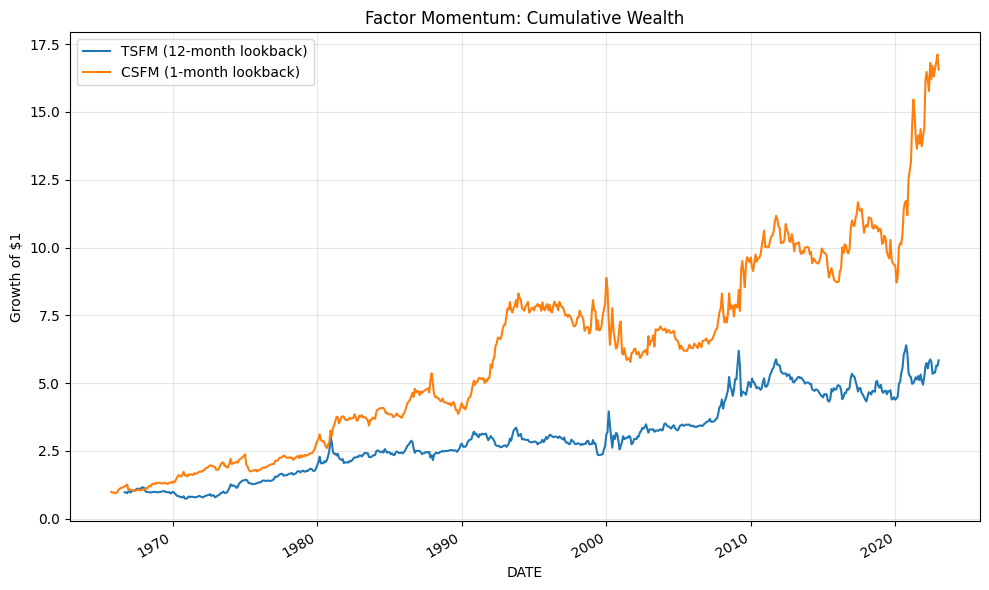

In [24]:
lag_ret = factors.shift(1)
csfm_returns = []

for date in factors.index:
    ranking = lag_ret.loc[date].dropna()
    if len(ranking) < 4:
        csfm_returns.append(np.nan)
        continue
    sorted_factors = ranking.sort_values()
    bottom2, top2 = sorted_factors.index[:2], sorted_factors.index[-2:]
    ret_today = factors.loc[date]
    csfm_returns.append(ret_today[top2].mean() - ret_today[bottom2].mean())

csfm = pd.Series(csfm_returns, index=factors.index, name='CSFM').dropna()
csfm_wealth = strategy_stats(csfm, 'CSFM')

# Plot both strategies
fig, ax = plt.subplots(figsize=(10, 6))
tsfm_wealth.plot(ax=ax, label='TSFM (12-month lookback)')
csfm_wealth.plot(ax=ax, label='CSFM (1-month lookback)')
ax.set_title('Factor Momentum: Cumulative Wealth')
ax.set_ylabel('Growth of $1')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

CSFM outperforms TSFM across all metrics (Sharpe 0.45 vs 0.30, t-stat 3.44 vs 2.28). The key conceptual difference: TSFM bets on absolute autocorrelation (did this factor do well?), while CSFM bets on relative performance (which factors did best vs worst?). CSFM also uses a 1-month lookback versus TSFM's 12-month window, capturing shorter-term factor persistence more effectively.

### 4.3 Spanning Tests: Are Factor Momentum Profits Explained by Known Factors?

A factor momentum strategy is only a genuine anomaly if its returns cannot be explained by
known risk factors. To test this, we regress the returns of each strategy (TSFM and CSFM)
on established factor models and examine whether a statistically significant alpha remains. We run two specifications.

**Regression 1:** Five-factor model
$$
R_{FMOM,t} = \alpha + \beta_{MKT}(Mkt-RF)_t + \beta_{SMB}SMB_t + \beta_{HML}HML_t + \beta_{RMW}RMW_t + \beta_{CMA}CMA_t + \varepsilon_t
$$

**Regression 2:** Six-factor model (add UMD)
$$
R_{FMOM,t} = \alpha + \beta_{MKT}(Mkt-RF)_t + \beta_{SMB}SMB_t + \beta_{HML}HML_t + \beta_{RMW}RMW_t + \beta_{CMA}CMA_t + \beta_{UMD}UMD_t + \varepsilon_t
$$

In [25]:
reg_data = pd.DataFrame({'TSFM': tsfm, 'CSFM': csfm}).join(
    ff[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'UMD']]).dropna()

X5 = reg_data[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']]
X6 = reg_data[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'UMD']]

for strat_name in ['TSFM', 'CSFM']:
    for label, X in [('5-Factor', X5), ('6-Factor (+ UMD)', X6)]:
        model = sm.OLS(reg_data[strat_name], sm.add_constant(X)).fit()
        print(f"\n{'='*60}")
        print(f"{strat_name} — {label}")
        print(f"{'='*60}")
        print(model.summary())


TSFM — 5-Factor
                            OLS Regression Results                            
Dep. Variable:                   TSFM   R-squared:                       0.119
Model:                            OLS   Adj. R-squared:                  0.110
Method:                 Least Squares   F-statistic:                     12.64
Date:                Fri, 03 Apr 2026   Prob (F-statistic):           1.56e-11
Time:                        12:00:41   Log-Likelihood:                 898.72
No. Observations:                 473   AIC:                            -1785.
Df Residuals:                     467   BIC:                            -1760.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0058      0.002   

TSFM has a significant five-factor alpha (0.58%/month, t = 3.33), but it drops to insignificance when UMD is added (0.18%, t = 1.25) with UMD loading at 0.51 (t = 15.6). This makes sense — TSFM's 12-month lookback mirrors how UMD is constructed. CSFM's alpha, however, barely changes when UMD is added (0.34% → 0.31%) with a tiny, insignificant UMD loading (0.04, t = 0.88). CSFM captures a short-term effect that stock momentum doesn't explain at all.

This supports the papers' central argument: factor momentum is more fundamental than stock momentum. UMD explains TSFM because they share a similar lookback, but CSFM — which captures pure factor-level relative momentum — is completely independent of UMD.

---
## 5. Long-Only Factor Rotation

The strategies above take both long and short positions in factors. In practice, many investors cannot short factors. This section builds a more realistic long-only rotation strategy and compares it against a passive equal-weight benchmark.

                          EW       FMR
Ann. excess return  0.027476  0.023603
Ann. std            0.046407  0.093941
Sharpe              0.592054  0.251252
Sortino             0.922626  0.333531
Max drawdown       -0.118396 -0.381485
Calmar              0.232066  0.061871
t-stat              3.752271  1.592366


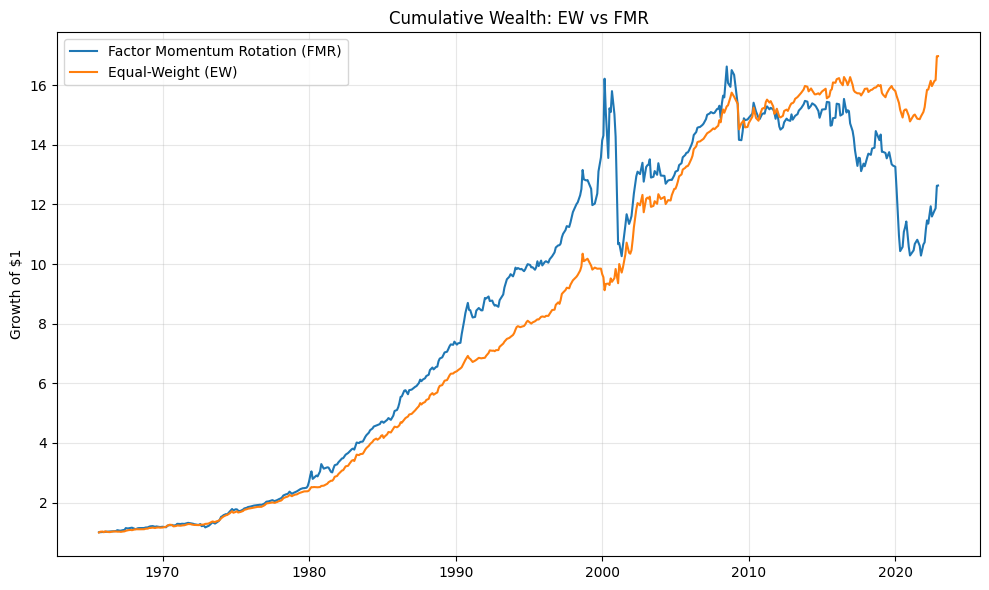

In [26]:
panel = pd.DataFrame({'HML': hml, 'PMU': pmu, 'CMA': cma, 'UMD': umd}).join(
    ff[['RF']], how='inner').dropna().copy()
factor_cols = ['HML', 'PMU', 'CMA', 'UMD']

# EW benchmark: 25% in each factor every month
ew_total = panel['RF'] + panel[factor_cols].mean(axis=1)

# FMR: long only factors with positive prior-12m average return
prior_12m = panel[factor_cols].rolling(12).mean().shift(1)
fmr_excess = []
for dt in panel.index:
    rets = panel.loc[dt, factor_cols]
    sig = prior_12m.loc[dt]
    chosen = rets[sig > 0]
    fmr_excess.append(chosen.mean() if len(chosen) > 0 else 0.0)

fmr_excess = pd.Series(fmr_excess, index=panel.index)
fmr_total = panel['RF'] + fmr_excess

# Performance comparison
def performance_stats(total_ret, rf):
    excess = total_ret - rf
    mean_m, std_m = excess.mean(), excess.std()
    ann_mean, ann_std = mean_m * 12, std_m * np.sqrt(12)
    downside = excess.clip(upper=0)
    downside_dev = np.sqrt((downside**2).mean())
    wealth = (1 + total_ret).cumprod()
    max_dd = (wealth / wealth.cummax() - 1).min()
    return pd.Series({
        'Ann. excess return': ann_mean, 'Ann. std': ann_std,
        'Sharpe': ann_mean / ann_std,
        'Sortino': ann_mean / (downside_dev * np.sqrt(12)),
        'Max drawdown': max_dd,
        'Calmar': ann_mean / abs(max_dd),
        't-stat': mean_m / (std_m / np.sqrt(len(excess)))
    }), wealth

ew_stats, ew_wealth = performance_stats(ew_total, panel['RF'])
fmr_stats, fmr_wealth = performance_stats(fmr_total, panel['RF'])

results = pd.concat([ew_stats, fmr_stats], axis=1)
results.columns = ['EW', 'FMR']
print(results)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(fmr_wealth.index, fmr_wealth.values, label='Factor Momentum Rotation (FMR)')
ax.plot(ew_wealth.index, ew_wealth.values, label='Equal-Weight (EW)')
ax.set_title('Cumulative Wealth: EW vs FMR')
ax.set_ylabel('Growth of $1')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In this sample, the simple equal-weight benchmark outperforms FMR on every metric (Sharpe 0.59 vs 0.25). With only four factors, the momentum signal is too unstable for reliable long-only timing; one factor having a bad run can dominate the entire portfolio. The papers analyze 20–47 factors where the signal is much more diversified. This highlights an important gap between the academic finding (factor momentum exists) and practical implementation (exploiting it requires a large factor universe).

---
## 6. Extension: Principal Component Factor Momentum

Ehsani & Linnainmaa and Arnott et al. show that factor momentum concentrates in the highest-eigenvalue principal components — the systematic directions that explain the most variation in returns. The economic intuition is that arbitrageurs can easily correct mispricings in low-eigenvalue directions, so only sentiment-driven mispricings in the most systematic factor combinations persist long enough to generate momentum.

This section extracts rolling PCs from our four factors, tests whether momentum concentrates in high-eigenvalue PCs, and builds a PC-based rotation strategy.

Average eigenvalue distribution:
  PC1: 1.979  (49.5%)
  PC2: 1.110  (27.8%)
  PC3: 0.624  (15.6%)
  PC4: 0.286  (7.2%)

PC1+PC2: 77.2%  |  PC3+PC4: 22.8%

MOMENTUM CONCENTRATION TEST
  High-EV (PC1-2):  Sharpe = 0.291,  t = 2.08
  Low-EV  (PC3-4):  Sharpe = 0.213,  t = 1.53
  All PCs (PC1-4):  Sharpe = 0.439,  t = 3.14

PERFORMANCE COMPARISON
                  EW      FMR   PC-FMR
Ann. excess   0.0306   0.0273  -0.0112
Ann. std      0.0467   0.0973   0.0821
Sharpe        0.6551   0.2801  -0.1369
Sortino       1.0327   0.3701  -0.1966
Max DD       -0.1184  -0.3815  -0.2560
Calmar        0.2586   0.0714  -0.0439
t-stat          3.92     1.65    -0.82


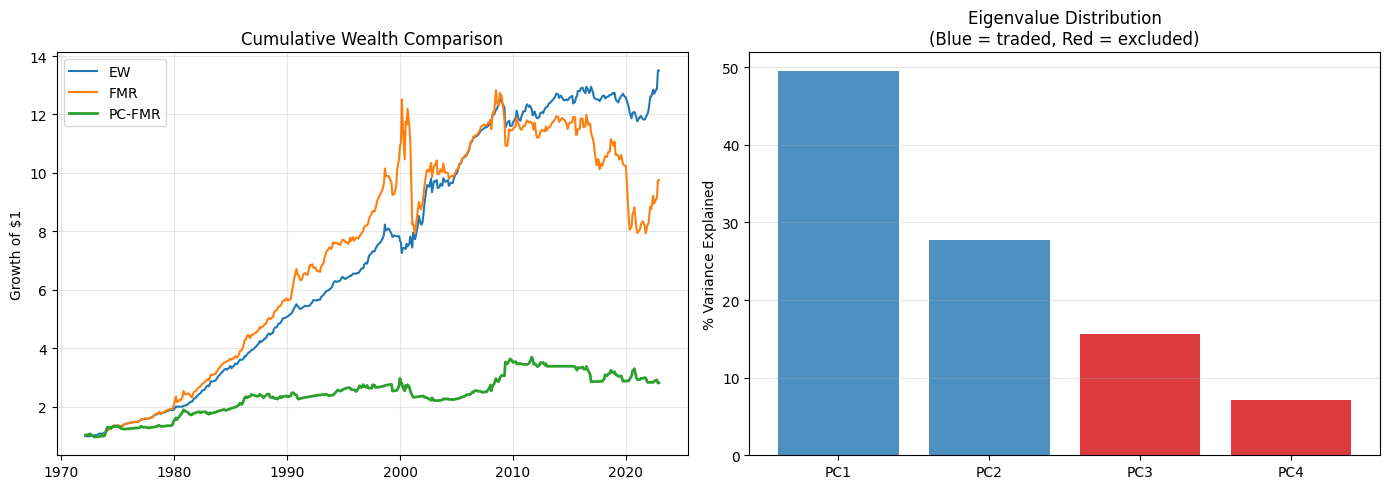

In [27]:
factor_cols = ['HML', 'PMU', 'CMA', 'UMD']
pc_window = 60  # 5-year rolling window

# Extract rolling PCs
pc_returns = []
ev_list = []

for i in range(pc_window, len(factors)):
    window = factors.iloc[i-pc_window:i][factor_cols]
    means, stds = window.mean(), window.std()
    if (stds < 1e-10).any():
        continue

    standardized = ((window - means) / stds).values
    corr = np.corrcoef(standardized.T)

    try:
        evals, evecs = np.linalg.eigh(corr)
    except np.linalg.LinAlgError:
        continue

    evals, evecs = evals[::-1], evecs[:, ::-1]
    ev_list.append(evals)

    month_i_std = ((factors.iloc[i][factor_cols] - means) / stds).values
    pc_returns.append(pd.Series(evecs.T @ month_i_std,
                                index=['PC1','PC2','PC3','PC4'],
                                name=factors.index[i]))

pc_returns = pd.DataFrame(pc_returns)

# Rescale PCs to match average raw factor volatility
target_vol = factors[factor_cols].std().mean()
for col in pc_returns.columns:
    pc_returns[col] *= target_vol / pc_returns[col].std()

# Eigenvalue distribution
avg_ev = np.mean(ev_list, axis=0)
total = avg_ev.sum()
print("Average eigenvalue distribution:")
for j, name in enumerate(['PC1','PC2','PC3','PC4']):
    print(f"  {name}: {avg_ev[j]:.3f}  ({avg_ev[j]/total*100:.1f}%)")
print(f"\nPC1+PC2: {(avg_ev[0]+avg_ev[1])/total*100:.1f}%  |  PC3+PC4: {(avg_ev[2]+avg_ev[3])/total*100:.1f}%")

# Momentum concentration test
print("\n" + "="*60)
print("MOMENTUM CONCENTRATION TEST")
print("="*60)

def tsfm_stats(ret_df, cols, label):
    prior = ret_df[cols].rolling(12).mean().shift(1)
    strat = []
    for dt in ret_df.index:
        sig, ret = prior.loc[dt], ret_df.loc[dt, cols]
        if sig.isna().any():
            strat.append(np.nan); continue
        long_r = ret[sig > 0].mean() if (sig > 0).any() else 0
        short_r = ret[sig <= 0].mean() if (sig <= 0).any() else 0
        strat.append(long_r - short_r)
    s = pd.Series(strat, index=ret_df.index).dropna()
    sharpe = s.mean()*12 / (s.std()*np.sqrt(12))
    t = s.mean() / (s.std()/np.sqrt(len(s)))
    print(f"  {label}:  Sharpe = {sharpe:.3f},  t = {t:.2f}")

tsfm_stats(pc_returns, ['PC1','PC2'], "High-EV (PC1-2)")
tsfm_stats(pc_returns, ['PC3','PC4'], "Low-EV  (PC3-4)")
tsfm_stats(pc_returns, ['PC1','PC2','PC3','PC4'], "All PCs (PC1-4)")

# PC-FMR strategy
pc_panel = pc_returns.join(ff[['RF']], how='inner').dropna()
prior_12m_pc = pc_panel[['PC1','PC2']].rolling(12).mean().shift(1)

pc_fmr_excess = []
for dt in pc_panel.index:
    sig = prior_12m_pc.loc[dt]
    if sig.isna().any():
        pc_fmr_excess.append(np.nan); continue
    chosen = pc_panel.loc[dt, ['PC1','PC2']][sig > 0]
    pc_fmr_excess.append(chosen.mean() if len(chosen) > 0 else 0.0)

pc_fmr_excess = pd.Series(pc_fmr_excess, index=pc_panel.index).dropna()
pc_fmr_total = pc_panel.loc[pc_fmr_excess.index, 'RF'] + pc_fmr_excess

# Compare all strategies on common dates
dates = pc_fmr_total.dropna().index.intersection(panel.dropna().index)
rf_common = panel.loc[dates, 'RF']

strategies = {'EW': panel.loc[dates, 'RF'] + panel.loc[dates, factor_cols].mean(axis=1)}

prior_raw = panel.loc[dates, factor_cols].rolling(12).mean().shift(1)
fmr_ex = []
for dt in dates:
    sig = prior_raw.loc[dt]
    if sig.isna().any():
        fmr_ex.append(np.nan); continue
    chosen = panel.loc[dt, factor_cols][sig > 0]
    fmr_ex.append(chosen.mean() if len(chosen) > 0 else 0.0)
strategies['FMR'] = panel.loc[dates, 'RF'] + pd.Series(fmr_ex, index=dates)
strategies['PC-FMR'] = pc_fmr_total.loc[dates]

# Performance table
def perf(total, rf):
    ex = total - rf
    m, s = ex.mean(), ex.std()
    wealth = (1 + total).cumprod()
    dd = (wealth / wealth.cummax() - 1).min()
    ds = np.sqrt((ex.clip(upper=0)**2).mean())
    return pd.Series({
        'Ann. excess':  f'{m*12:.4f}', 'Ann. std': f'{s*np.sqrt(12):.4f}',
        'Sharpe': f'{m*12/(s*np.sqrt(12)):.4f}',
        'Sortino': f'{m*12/(ds*np.sqrt(12)):.4f}',
        'Max DD': f'{dd:.4f}', 'Calmar': f'{m*12/abs(dd):.4f}',
        't-stat': f'{m/(s/np.sqrt(len(ex))):.2f}'
    })

results = pd.DataFrame({name: perf(ret.dropna(), rf_common.loc[ret.dropna().index])
                         for name, ret in strategies.items()})
print("\n" + "="*60)
print("PERFORMANCE COMPARISON")
print("="*60)
print(results)

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, ret in strategies.items():
    wealth = (1 + ret.dropna()).cumprod()
    axes[0].plot(wealth.index, wealth.values, label=name, linewidth=1.5 + (name=='PC-FMR')*0.5)
axes[0].set_title('Cumulative Wealth Comparison')
axes[0].set_ylabel('Growth of $1')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

pct = avg_ev / avg_ev.sum() * 100
axes[1].bar(['PC1','PC2','PC3','PC4'], pct,
            color=['#2c7bb6','#2c7bb6','#d7191c','#d7191c'], alpha=0.85)
axes[1].set_ylabel('% Variance Explained')
axes[1].set_title('Eigenvalue Distribution\n(Blue = traded, Red = excluded)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

The momentum concentration test confirms the papers' prediction: PC1 and PC2 capture 77.2% of variance and show significant momentum (Sharpe 0.29, t = 2.08), while PC3 and PC4 do not (Sharpe 0.21, t = 1.53). The combined long-short TSFM across all PCs earns a Sharpe of 0.44 (t = 3.14).

However, the long-only PC-FMR strategy underperforms. This is not overfitting; it's structural. PCs are centered at zero by construction, so the "was this PC positive over the last year?" signal is inherently noisier than asking the same question of a raw factor like HML that has a positive long-run mean. The long-short version works because it exploits relative differences between winning and losing PCs; the long-only version requires PCs to stay consistently positive, which they don't.

This illustrates an important implementation lesson: the factor momentum signal is real and concentrates in high-eigenvalue directions as theory predicts, but translating it into a practical long-only strategy requires a much larger factor universe (the papers use 20–47 factors) where PCs are more stable.

---
## Conclusion

This project provides direct empirical support for the factor momentum hypothesis:

1. **Factors are autocorrelated.** HML and PMU both show statistically significant persistence, with HML being the strongest (t = 3.33).

2. **UMD dynamically times other factors.** The conditional correlation analysis reveals that UMD's relationship with other factors flips sign depending on their recent performance — positive after good years, negative after bad ones. This is invisible in unconditional statistics and explains why standard factor models fail to explain momentum.

3. **Factor momentum generates significant alpha.** Both TSFM and CSFM produce returns unexplained by the five-factor model. Crucially, CSFM is completely independent of stock-level UMD, supporting the view that factor momentum is more fundamental than individual stock momentum.

4. **Momentum concentrates in high-eigenvalue PCs.** Consistent with the theoretical prediction that persistent sentiment affects only the most systematic factor combinations.

5. **Implementation requires scale.** With only four factors, the momentum signal is too noisy for reliable long-only rotation. The academic results (using 20–47 factors) rely on diversification across many factor bets.

The overarching takeaway aligns with Ehsani & Linnainmaa: momentum is not a separate anomaly — it is what happens when you sort stocks by past returns and inadvertently load on whichever factors are currently in a streak.